<a href="https://colab.research.google.com/github/Riky-18/EDA-Tasks/blob/main/PCA_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Wine Quality Dataset - Principal Component Analysis (PCA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Data Loading and Initial Exploration

In [2]:
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

red_wine['wine_type'] = 'red'
white_wine['wine_type'] = 'white'

df = pd.concat([red_wine, white_wine], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


df.info()

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


Preprocessing & Handling Missing Values

In [4]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [5]:
features = [col for col in df.columns if col not in ['quality', 'wine_type']]
X = df[features]
y = df['quality']
wine_type = df['wine_type']

print(f"Features: {features}")
print(f"Matrix shape: {X.shape}")

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Matrix shape: (6497, 11)


Feature Standardization

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464
1,0.451036,3.282235,-2.192833,-0.597640,1.197975,-0.311320,-0.862469,0.701486,-0.115073,0.999579,-0.580068
2,0.451036,2.553300,-1.917553,-0.660699,1.026697,-0.874763,-1.092486,0.768188,0.258120,0.797958,-0.580068
3,3.073817,-0.362438,1.661085,-0.744778,0.541412,-0.762074,-0.986324,1.101694,-0.363868,0.327510,-0.580068
4,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464


PCA - Scree Plot & Explained Variance

In [7]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i:02d}: Individual Variance = {var*100:.2f}% | Cumulative = {cum_var*100:.2f}%")

PC01: Individual Variance = 27.54% | Cumulative = 27.54%
PC02: Individual Variance = 22.67% | Cumulative = 50.22%
PC03: Individual Variance = 14.15% | Cumulative = 64.36%
PC04: Individual Variance = 8.82% | Cumulative = 73.19%
PC05: Individual Variance = 6.54% | Cumulative = 79.73%
PC06: Individual Variance = 5.52% | Cumulative = 85.25%
PC07: Individual Variance = 4.76% | Cumulative = 90.01%
PC08: Individual Variance = 4.56% | Cumulative = 94.57%
PC09: Individual Variance = 3.06% | Cumulative = 97.63%
PC10: Individual Variance = 2.07% | Cumulative = 99.70%
PC11: Individual Variance = 0.30% | Cumulative = 100.00%


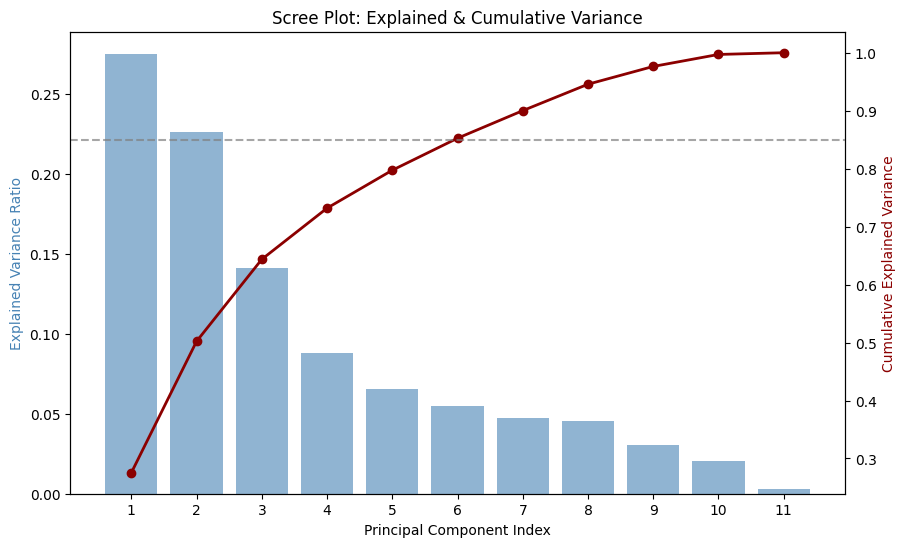

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x_axis = range(1, len(explained_variance) + 1)

ax1.bar(x_axis, explained_variance, alpha=0.6, color='steelblue', label='Individual Variance')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Explained Variance Ratio', color='steelblue')
ax1.set_xticks(x_axis)

ax2 = ax1.twinx()
ax2.plot(x_axis, cumulative_variance, color='darkred', marker='o', linewidth=2, label='Cumulative Variance')
ax2.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)
ax2.set_ylabel('Cumulative Explained Variance', color='darkred')

plt.title('Scree Plot: Explained & Cumulative Variance')
plt.show()

Dimensionality Reduction & 2D Projection

In [9]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['wine_type'] = wine_type.values
df_pca['quality'] = y.values
df_pca.head()

,PC1,PC2,wine_type,quality
0,-3.205996,0.416523,red,5
1,-3.039051,1.107462,red,5
2,-3.071893,0.878964,red,5
3,-1.571262,2.112545,red,6
4,-3.205996,0.416523,red,5


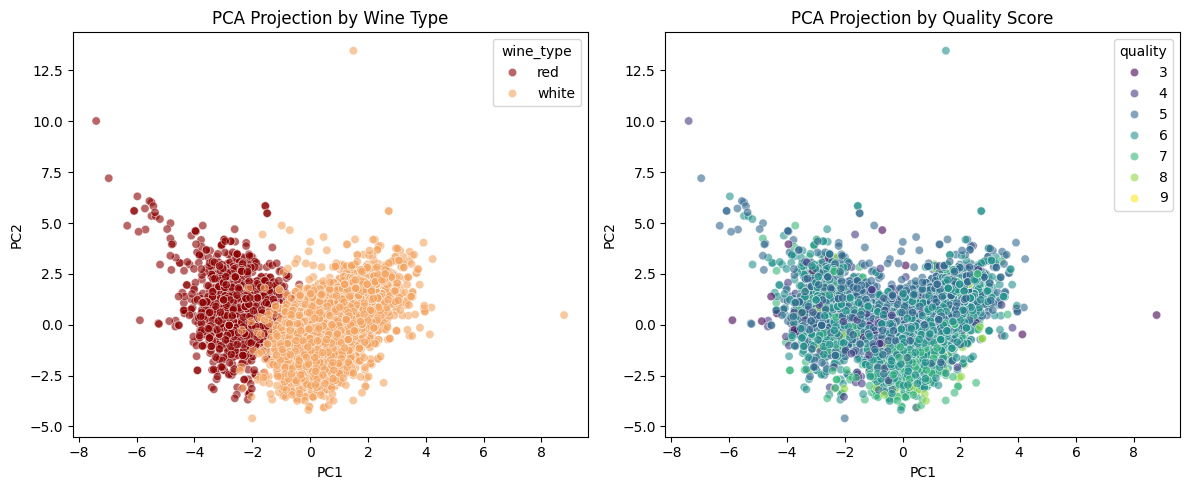

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='wine_type', palette={'red': '#8B0000', 'white': '#F4A460'}, alpha=0.6)
plt.title('PCA Projection by Wine Type')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='quality', palette='viridis', alpha=0.6)
plt.title('PCA Projection by Quality Score')

plt.tight_layout()
plt.show()

Dimension Comparison & Factor Loadings

Original Feature Dimension: 11
2D Reduced Dimension:       2


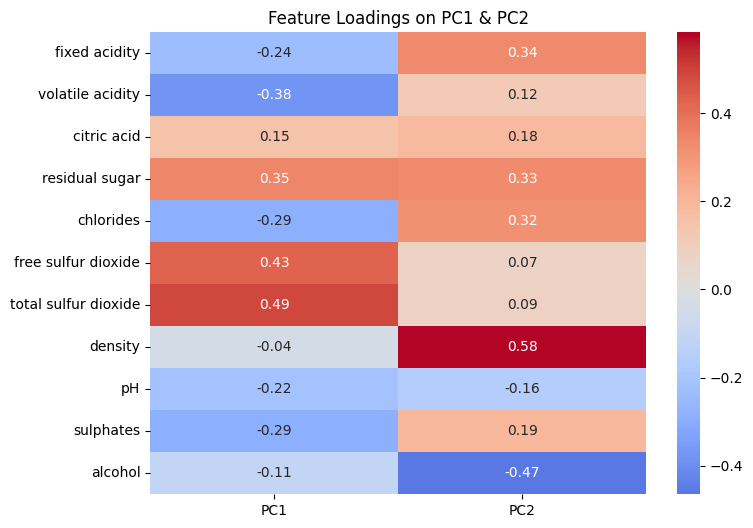

In [11]:
print(f"Original Feature Dimension: {X.shape[1]}")
print(f"2D Reduced Dimension:       {X_pca_2d.shape[1]}")

loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Loadings on PC1 & PC2')
plt.show()

Quantitative Results & Interpretation

In [12]:
var_2d = explained_variance[:2].sum() * 100
n_85 = np.argmax(cumulative_variance >= 0.85) + 1
var_n85 = cumulative_variance[n_85 - 1] * 100

print(f"Original Dimensions : {X.shape[1]} features")
print(f"2D Reduction        : 2 components retain {var_2d:.2f}% variance ({100 - var_2d:.2f}% info lost)")
print(f"Optimal Reduction   : {n_85} components needed to preserve >= 85% variance ({var_n85:.2f}%)")
print(f"Dimension Reduction : {((X.shape[1] - n_85) / X.shape[1]) * 100:.1f}% reduction in features")

Original Dimensions : 11 features
2D Reduction        : 2 components retain 50.22% variance (49.78% info lost)
Optimal Reduction   : 6 components needed to preserve >= 85% variance (85.25%)
Dimension Reduction : 45.5% reduction in features


In [13]:
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(3)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(3)

interpretation_df = pd.DataFrame({
    'PC1 Dominant Features': [f"{idx} ({loadings.loc[idx, 'PC1']:+.2f})" for idx in top_pc1.index],
    'PC2 Dominant Features': [f"{idx} ({loadings.loc[idx, 'PC2']:+.2f})" for idx in top_pc2.index]
}, index=['Rank 1', 'Rank 2', 'Rank 3'])

interpretation_df

,PC1 Dominant Features,PC2 Dominant Features
Rank 1,total sulfur dioxide (+0.49),density (+0.58)
Rank 2,free sulfur dioxide (+0.43),alcohol (-0.47)
Rank 3,volatile acidity (-0.38),fixed acidity (+0.34)


In [14]:
component_corrs = df_pca[['PC1', 'PC2', 'quality']].corr()['quality'].drop('quality')

print("Correlation with Wine Quality:")
for pc, corr in component_corrs.items():
    direction = "positive" if corr > 0 else "negative"
    print(f"{pc}: r = {corr:.3f} ({direction} correlation with quality)")

Correlation with Wine Quality:
PC1: r = 0.076 (positive correlation with quality)
PC2: r = -0.315 (negative correlation with quality)


In [15]:
type_means = df_pca.groupby('wine_type')[['PC1', 'PC2']].mean()
separation_distance = np.linalg.norm(type_means.loc['red'] - type_means.loc['white'])

print("Wine Type Cluster Separation:")
display(type_means)
print(f"Euclidean distance between Red & White cluster centers in 2D: {separation_distance:.2f}")

Wine Type Cluster Separation:


,PC1,PC2
wine_type,,
red,-2.514621,0.775724
white,0.820923,-0.253243


Euclidean distance between Red & White cluster centers in 2D: 3.49
